# 05 - COVID-19 Temporal Analysis

This notebook analyzes how did **cases and deaths evolve over time** and which **events changed its behavior (lockdown, restrictions, vaccinations)**.

Includes:
* Cases and deaths (per capita)
* Moving averages
* Key dates:
    - First global lockdown
    - Initial restrictions
    - Initial vaccination 

Objective:
> Detect structural changes

## Import Libraries

In [1]:
import os
from pathlib import Path

project_root = Path.cwd()
if project_root.name == 'notebooks':
    project_root = project_root.parent
os.chdir(project_root)

In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Import the data loader module
from src.data_loader import change_dtypes
from src.visualization import set_style

# Set visualization style
set_style(palette="Blues_d")

print('Libraries imported successfully!')

Libraries imported successfully!


## Load Data

In [5]:
countries = pd.read_csv("data/processed/countries.csv", parse_dates=["date"])
countries.head()

,country,date,total_cases,new_cases,new_cases_smoothed,total_cases_per_million,new_cases_per_million,new_cases_smoothed_per_million,total_deaths,new_deaths,...,continent,population,population_density,median_age,life_expectancy,gdp_per_capita,extreme_poverty,diabetes_prevalence,handwashing_facilities,hospital_beds_per_thousand
0,Afghanistan,2020-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,Asia,40578847.0,62.215549,16.752001,65.616997,1516.273315,2.436315,10.9,51.938343,0.39
1,Afghanistan,2020-01-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,Asia,40578847.0,62.215549,16.752001,65.616997,1516.273315,2.436315,10.9,51.938343,0.39
2,Afghanistan,2020-01-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,Asia,40578847.0,62.215549,16.752001,65.616997,1516.273315,2.436315,10.9,51.938343,0.39
3,Afghanistan,2020-01-04,0.0,0.0,NaN,0.0,0.0,NaN,0.0,0.0,...,Asia,40578847.0,62.215549,16.752001,65.616997,1516.273315,2.436315,10.9,51.938343,0.39
4,Afghanistan,2020-01-05,0.0,0.0,NaN,0.0,0.0,NaN,0.0,0.0,...,Asia,40578847.0,62.215549,16.752001,65.616997,1516.273315,2.436315,10.9,51.938343,0.39


## Global Evolution of Cases

Here we are going to see how cases evolved.

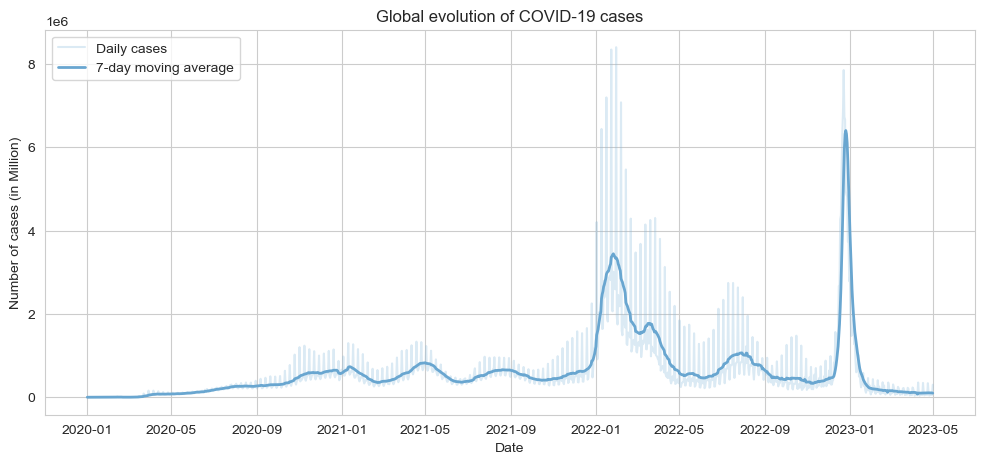

In [48]:
global_cases = (
    countries
    .groupby("date", as_index=False)["new_cases"]
    .sum()
)

global_cases["cases_ma7"] = global_cases["new_cases"].rolling(7).mean().fillna(0)

# Graph
plt.figure(figsize=(12, 5))
plt.plot(global_cases["date"], global_cases["new_cases"], alpha=0.3, label="Daily cases")
plt.plot(global_cases["date"], global_cases["cases_ma7"], linewidth=2, label="7-day moving average")

plt.title("Global evolution of COVID-19 cases")
plt.xlabel("Date")
plt.ylabel("Number of cases (in Million)")
plt.legend()
plt.show()

> Observation: as we can see in the daily cases lines and in our data, new cases are very volatile as sometimes there are no report cases at all (weekends) or some days there are a lot of them. That is why we choose to use the moving average as the line of tendency, because we can see more clearely the cases over time.

Also, we can see that there were big waves on early 2022 and 2023.

But... what happened in the early stages of the virus? We are going to see what happened on the first year 2020 and important dates.

### 2020 - The Beginning of the COVID

This is one of the news reporting that the first COVID-19 case was detected on 17 November 2019, according to the China government.

<img src="../img/first_covid_case.png" width="600">

After this first case was reported, the cases started to grow, and since **11 March 2020** COVID-19 has been a pandemic.

This is the early stage of the pandemic, until June 2020.

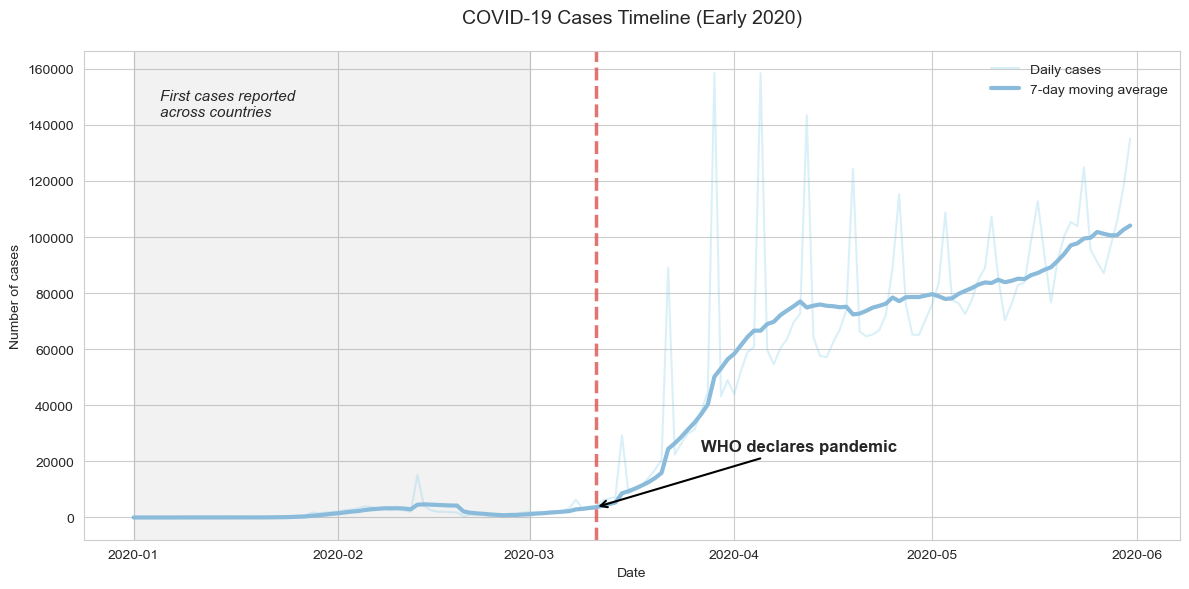

In [93]:
global_cases_2020 = global_cases.query("date < '2020/06'")

set_style(palette="Blues_d")

# Graph
plt.figure(figsize=(12, 6))

# Daily cases
sns.lineplot(data=global_cases_2020, x="date", y="new_cases", 
             alpha=0.3, label="Daily cases", color="skyblue")

# moving average
sns.lineplot(data=global_cases_2020, x="date", y="cases_ma7", 
             linewidth=3, label="7-day moving average")

# --- ANNOTATIONS ---

# A. Period: First cases reported (Jan to March)
plt.axvspan(pd.Timestamp("2020-01-01"), pd.Timestamp("2020-03-01"), 
            color='gray', alpha=0.1)
plt.text(pd.Timestamp("2020-01-05"), plt.ylim()[1]*0.86, 
         "First cases reported\nacross countries", 
         fontsize=11, fontstyle='italic')

# B. WHO Pandemic Declaration (March 11)
pandemic_date = pd.Timestamp("2020-03-11")
plt.axvline(x=pandemic_date, color='#d9534f', linestyle='--', alpha=0.8, lw=2.5) # Rojo suave

y_value = global_cases_2020.loc[global_cases_2020["date"] == pandemic_date, "cases_ma7"].values[0]

plt.annotate('WHO declares pandemic', 
             xy=(pandemic_date, y_value),
             xytext=(pd.Timestamp("2020-03-27"), y_value + (plt.ylim()[1]*0.12)),
             arrowprops=dict(arrowstyle='->', color='black', lw=1.5),
             fontsize=12, fontweight='bold')

plt.title("COVID-19 Cases Timeline (Early 2020)", fontsize=14, pad=20)
plt.xlabel("Date")
plt.ylabel("Number of cases")
plt.legend(frameon=False)

plt.tight_layout()
plt.show()

## Global Evolution of Deaths

## Comparison (Cases vs. Deaths)

## Lockdown and Restriction

## Vaccination

## Summary